In [66]:
import numpy as np 
from matplotlib import pyplot as plt
plt.rcParams.update({'font.size': 16})
import pandas as pd
import random as rand

In [2]:
#soil moisture loss function
def loss_func (ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss):
    if (ss <= sh):
        losses = 0
    elif ((ss > sh) and (ss <= sw)):
        losses = (ET_w/(n*Zr))*((ss-sh)/(sw-sh))
    elif ((ss > sw) and (ss <= s1)):
        losses = (ET_w + (ET_max - ET_w)*((ss-sw)/(s1-sw)))/(n*Zr)
    elif ((ss > s1) and (ss <= sfc)):
        losses = (ET_max/(n*Zr))
    else:
        losses = (ET_max/(n*Zr))+(1/(n*Zr))*(Ks/(np.exp(beta*(1-sfc))-1) * ((np.exp(beta*(ss-sfc))) - 1 ))
        
    return losses

# Soil Properties
def soil(x):
    if x == "loamy sand":
        n = 0.42 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [mm/day] at wilting point
        phis = -0.17*10**-3 #(MPa)
        b = 4.38
        sfc = 0.52 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.31 # soil moisture at onset of plant stress
        beta = 12.7 # soil term to calculate K(s) decay as part of leakage term
        Ks = 100 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.1362 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "sand":
        n = 0.35 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -0.34*10**-3 #(MPa)
        b = 4.05
        sfc = 0.35 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.33 # soil moisture at onset of plant stress
        beta = 12.1 # soil term to calculate K(s) decay as part of leakage term
        Ks = 200 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.154 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "loam":
        n = 0.45 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -1.43*10**-3 #(MPa)
        b = 5.39
        sfc = 0.65 # soil moisture at field capacity
        sw = 0.24 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.57 # soil moisture at onset of plant stress
        beta = 13.8 # soil term to calculate K(s) decay as part of leakage term
        Ks= 20 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)
        nn = 0.18 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "sandy loam":
        n = 0.43 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -0.7*10**-3 #(MPa)
        b = 4.9
        sfc = 0.56 # soil moisture at field capacity
        sw = 0.18 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.46 # soil moisture at onset of plant stress
        beta = 12.8 # soil term to calculate K(s) decay as part of leakage term
        Ks= 80 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)
        nn = 0.18 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    else:
        pass
    return n, b, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22

# Response of biotic H2 consuming bacteria to soil moisture 
def fh(ss):
    if ss <= swh:
        fs=0
    else:
        fs = (((ss-swh)**beta1)*((1-ss)**beta2))/(((sopt-swh)**beta1)*((1-sopt)**beta2))
    return fs

def fhm(ss):
    if ss <= sw:
        fs=0
    else:
        fs = (((ss-sw)**beta1)*((1-ss)**beta22))/(((sopt-sw)**beta1)*((1-sopt)**beta22))
    return fs

# Response of Organic Carbon consuming bacteria to soil moisture
def fc(ss):
    if ss <= sw:
        fs=0
    elif sw < ss <= sfc:
        fs = (ss - sw)/(sfc - sw)
    else:
        fs = sfc/ss
    return fs
#total conductance of the soil and diffusive barrier
def gt(s,d,sp,k):
    D0 = 0.756
    a1 = 1 #alpha1
    a2 = 2 #alpha2
    a3 = 2+3/b
    ls = np.sqrt((D0 * a1 * (n**a2) * (1-s)**a3)/k)
    gs = (D0 * a1 * (n**a2) * (1-s)**a3)/ls
    gd = D0 * a1 * (sp**a2)/d
    gt = (gs * gd)/(gs + gd)
    return gt

# Temperature dependence
def temp(T): #T in celcius
    if T<=40:
        ht = 1/(1+np.exp(-(T-3.8)/6.7))
    else:
        ht = 1/(1+np.exp((T-62.2)/7.1))
    return ht
    
# H2 Diffusive flux
def ff(ss,d,H, sp, k):
    ff = gt(ss, d, sp, k)*(Ha-H)
    return ff

# h2 biological sink
def bd(s, Cs, Bh, t):
    bd = temp(t)*khh*fh(s)*Cs*Bh
    return bd

# Velocity that indicates the potential bological sink along depth Zr
def vbd(s, Cs, Bh, t):
    vbd = Zr*bd(s, Cs, Bh, t)
    return vbd
# Quasi steady approximation of H2 conecntration in the soil
def hyd(s, Cs, Bh, d, sp, k, t):
    hyd = Ha/(1 + (vbd(s, Cs, Bh, t)/gt(s,d, sp, k)))
    return hyd

def vd_do(s, d, sp, k, C, Bh, t):
    vd = (gt(s, d, sp, k)*vbd(s, C, Bh, t))/(gt(s, d, sp, k)+vbd(s, C, Bh, t))
    return vd

def vd_m(s, d, sp, t):
    vd = (gt(s, d, sp, km)*(km*fh(s)*temp(t)*Zr))/(gt(s, d, sp,km)+(km*fh(s)*temp(t)*Zr))
    return vd


x = "sandy loam"
n, b, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22 = soil(x)
dt = 0.001
Ha = 530

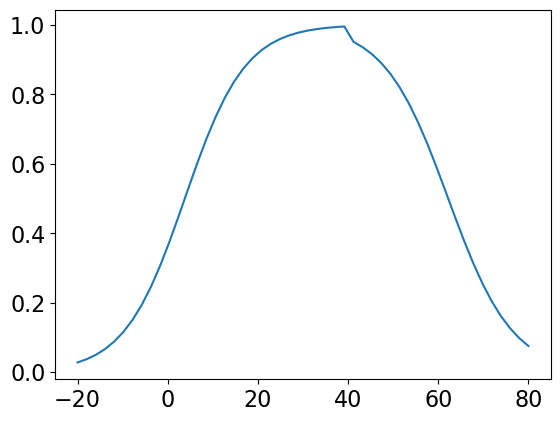

In [48]:
ttt = np.linspace(-20, 80)
tem = np.zeros(len(ttt))
for i in range(len(ttt)):
    tem[i] = temp(ttt[i])


plt.plot(ttt, tem)

In [72]:
ADD_max = 3.2 #g/m3/day
ADD_min = 0 #g/m3/day
khh = 4.2*10**-9 # Potential decomposition rate for hydrogen
kcc = 1.8*10**-4 # Potential decomposition rate for carbon
mc = 0.007 # Mortality rate for carbon microbes
mh = 0.008 # Mortality rate for Hydrogen microbes
rc = 0.5 # Respiration rate for Carbon microbes
rh = 0.5 # Respiration rate for Hydrogen microbes
q = 12*0.0072 # carbon to hydrogen ratio [C/H]

def ADD(s):
    ADD = ADD_max + (ADD_min - ADD_max)/(1 + (s/sfc)**3.31)
    return ADD

def substrate_sol(s, Bh, H, Cs, Bc, t):
    kc = kcc*temp(t)*fc(s)
    kh = khh*temp(t)*fh(s)
    DEC_c = kc*Cs*Bc
    DEC_h = q*kh*Cs*Bh*H*n*(1-s)
    BD_c = mc*Bc
    BD_h = mh*Bh
    cs = Cs + dt*(ADD(s) - DEC_c - DEC_h + BD_c + BD_h)
    return cs

def Microbe_c(s, Cs, Bc, t):
    kc = kcc*temp(t)*fc(s)
    DEC_c = kc*Cs*Bc
    BD_c = mc*Bc
    bc = Bc + dt*((1-rc)*DEC_c - BD_c)
    return bc

def Microbe_h(s, Bh, H, Cs, t):
    kh = khh*temp(t)*fh(s)
    DEC_h = q*kh*Cs*Bh*H*n*(1-s)
    BD_h = mh*Bh
    bh = Bh + dt*((1-rh)*DEC_h - BD_h)
    return bh

def run_hyd(s, s1, Bh, H, Cs, t):
    flux = ff(s, d, H, sp, k)
    b_d = bd(s, Cs, Bh, t)*H*Zr
    air = 1 - s
    H_vec = H + dt*(((flux - b_d))/(n*Zr*air)) + H*(s1 - s)/air
    if H_vec > Ha:
        H_vec = Ha
    return H_vec

In [4]:
h2 = pd.read_excel("H2 havard forest.xlsx", sheet_name="Sheet1")
ss_dry = h2.ss_dry
ss_wet = h2.ss_wet
ss_wet = ss_wet.replace(1, 0.99)
ss_m = h2.ss_mean
vd = h2.vd
stemp = h2.soilt
snow = h2.snow
spor = h2.snowp
days = np.linspace(1,len(ss_dry),len(ss_dry))
precip = h2.precip


C_vec_m = np.zeros(len(days))
C_vec_m [0] = 55000
Bc_vec_m  = np.zeros(len(days))
Bc_vec_m [0] = 0.8*337
Bh_vec_m  = np.zeros(len(days))
Bh_vec_m [0] = 0.2*337

d = snow[0] # thickness of snow/litter layer
sp = spor[0] # porosity of snow/litter layer
#k3, k1, k2 = khh*Bh_vec[0]*C_vec[0], khh*Bh_vec_d[0]*C_vec_d[0], khh*Bh_vec_m[0]*C_vec_m[0] # k1-dry, k2-mean, k3-wet
k = khh*fh(ss_m[0])*temp(stemp[0])*Bh_vec_m[0]*C_vec_m[0]

hyd_vec_m = np.zeros(len(days)) #Quasi steady approximation
hyd_vec_m[0] = hyd(ss_m[0], C_vec_m[0], Bh_vec_m[0], d, sp, k, stemp[0])

# Hydrogen conc.

H_vec_m = np.zeros(len(days))
H_vec_m[0] = 100

# Deposition velocity
Vdd_m = np.zeros(len(days))
Vdd_m[0] = vd_do(ss_m[0], d, sp, k, C_vec_m[0], Bh_vec_m[0], stemp[0])

In [73]:
# Sensitivity analysis
CC = np.linspace(55770, 424580, num = 10)
BCC = np.linspace(337, 5377, num = 10)
RA = np.linspace(0.01, 0.2, num=5)
nut = np.zeros(len(days))
data = pd.DataFrame({"NA": nut})
for rat in range(5):
    BHH = RA[rat]*BCC
    for p in range(10):
        for o in range(10):
            for w in range(10):
                C_vec_m[0], Bc_vec_m[0], Bh_vec_m[0] = CC[p], BCC[o], BHH[w]
                k = khh*fh(ss_m[0])*temp(stemp[0])*Bh_vec_m[0]*C_vec_m[0]
                Vdd_m[0] = vd_do(ss_m[0], d, sp, k, C_vec_m[0], Bh_vec_m[0], stemp[0])
                for i in range(1, len(days)):
                    d = snow[i]
                    sp = spor[i]
                    C_vec_m[i] = substrate_sol(ss_m[i-1], Bh_vec_m[i-1], H_vec_m[i-1], C_vec_m[i-1], Bc_vec_m[i-1], stemp[i]) #c with mean soil moisture
                    Bc_vec_m[i] = Microbe_c(ss_m[i-1], C_vec_m[i-1], Bc_vec_m[i-1], stemp[i])
                    H_vec_m[i] = run_hyd(ss_m[i-1], ss_m[i], Bh_vec_m[i-1], H_vec_m[i-1], C_vec_m[i-1], stemp[i])
                    Bh_vec_m[i] = Microbe_h(ss_m[i-1], Bh_vec_m[i-1], H_vec_m[i-1], C_vec_m[i-1], stemp[i])
                    k = khh*fh(ss_m[i])*temp(stemp[i])*Bh_vec_m[i]*C_vec_m[i]
                    Vdd_m[i] = vd_do(ss_m[i], d, sp, k, C_vec_m[i], Bh_vec_m[i], stemp[i])
                    ser = pd.Series(Vdd_m, name = f"vd_{p}_{o}_{w}")
                data = pd.concat([data,ser], axis=1)

data = data.drop("NA", axis=1)

In [74]:
std = data.std(axis=1)
mean = data.mean(axis=1)

In [ ]:
# Matteo Formulation for VD with only abiotic drivers
mVdd = np.zeros(len(days))
mVdd_d = np.zeros(len(days))
mVdd_m = np.zeros(len(days))


for i in range(len(days)):
    d = snow[i]
    sp = spor[i]
    #mVdd_d[i] = vd_m(ss_dry[i], d, sp, stemp[i])
    mVdd_m[i] = vd_m(ss_m[i], d, sp, stemp[i])
    #mVdd[i] = vd_m(ss_wet[i], d, sp, stemp[i])

In [ ]:
from datetime import date, timedelta

# Create a datetime array with a specific range
start_date = date(2010, 12, 1)
end_date = date(2012, 3, 1)
date_array = [start_date + timedelta(days=i) for i in range((end_date - start_date).days)]

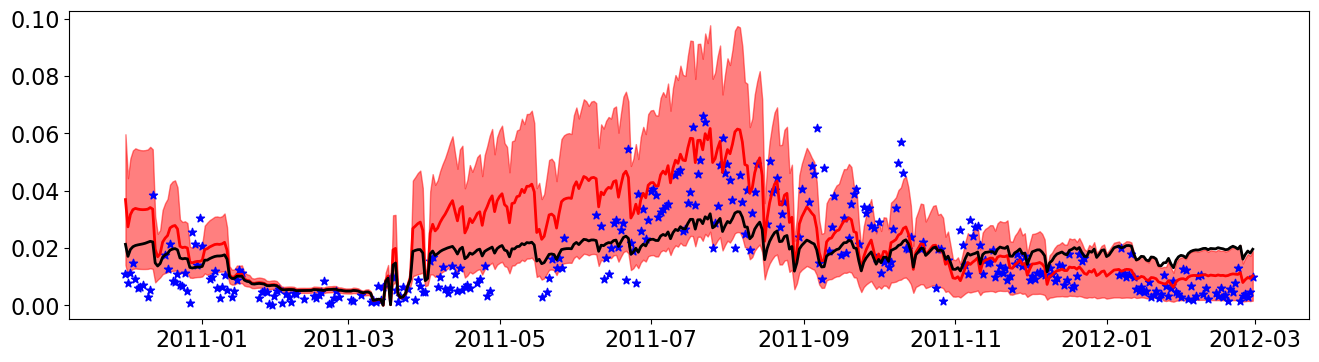

In [78]:
# Figure 9
plt.figure(figsize = (16,4))
#plt.fill_between(h2.date, mean-2*std, mean+2*std, color = "red", alpha = 0.5)
plt.fill_between(h2.date, mean-std, mean+std, color = "red", alpha = 0.5)
plt.plot(h2.date, mean , "r", linewidth = 2)
plt.plot(h2.date, mVdd_m, "k", linewidth = 2)
plt.scatter(h2.date, vd, marker = "*", color="blue" )
#plt.ylim([0, 0.1])
#plt.savefig("validation.png")
plt.show()

In [241]:
C_vec= np.zeros(len(days))
C_vec[0] = 350
Bc_vec = np.zeros(len(days))
Bc_vec[0] = 10
Bh_vec = np.zeros(len(days))
Bh_vec[0] = 4
C_vec_d  = np.zeros(len(days))
C_vec_d[0] = 350
Bc_vec_d = np.zeros(len(days))
Bc_vec_d[0] = 10
Bh_vec_d = np.zeros(len(days))
Bh_vec_d[0] = 4
H_vec = np.zeros(len(days))
H_vec[0] = hyd_vec[0]
H_vec_d = np.zeros(len(days))
H_vec_d[0] = hyd_vec_d[0]

hyd_vec = np.zeros(len(days)) #Quasi steady approximation
hyd_vec[0] = hyd(ss_wet[0], C_vec[0], Bh_vec[0], d, sp, k3, temp(stemp[0]))
hyd_vec_d = np.zeros(len(days)) #Quasi steady approximation
hyd_vec_d[0] = hyd(ss_dry[0], C_vec_d[0], Bh_vec_d[0], d, sp, k1, temp(stemp[0]))

Vdd = np.zeros(len(days))
Vdd[0] = vd_do(ss_wet[0], d, sp, k3, C_vec[0], Bh_vec[0], stemp[0])
Vdd_d = np.zeros(len(days))
Vdd_d[0] = vd_do(ss_dry[0], d, sp, k1, C_vec_d[0], Bh_vec_d[0], stemp[0])

In [6]:
for i in range(1, len(days)):
    d = snow[i]
    hh = temp(stemp[i])
    sp = spor[i]
    #C_vec_d[i] = substrate_sol(ss_dry[i-1], Bh_vec_d[i-1], H_vec_d[i-1], C_vec_d[i-1], Bc_vec_d[i-1], stemp[i]) #c with dry soil moisture
    C_vec_m[i] = substrate_sol(ss_m[i-1], Bh_vec_m[i-1], H_vec_m[i-1], C_vec_m[i-1], Bc_vec_m[i-1], stemp[i]) #c with mean soil moisture
    #C_vec[i] = substrate_sol(ss_wet[i-1], Bh_vec[i-1], H_vec[i-1], C_vec[i-1], Bc_vec[i-1], stemp[i]) #c with wet soil moisture
    
    #Bc_vec_d[i] = Microbe_c(ss_dry[i-1], C_vec_d[i-1], Bc_vec_d[i-1], stemp[i])
    Bc_vec_m[i] = Microbe_c(ss_m[i-1], C_vec_m[i-1], Bc_vec_m[i-1], stemp[i])
    #Bc_vec[i] = Microbe_c(ss_wet[i-1], C_vec[i-1], Bc_vec[i-1], stemp[i])
    
    #H_vec_d[i] = run_hyd(ss_dry[i-1], ss_dry[i], Bh_vec_d[i-1], H_vec_d[i-1], C_vec_d[i-1], stemp[i])
    H_vec_m[i] = run_hyd(ss_m[i-1], ss_m[i], Bh_vec_m[i-1], H_vec_m[i-1], C_vec_m[i-1], stemp[i])
    #H_vec[i] = run_hyd(ss_wet[i-1], ss_wet[i], Bh_vec[i-1], H_vec[i-1], C_vec[i-1], stemp[i])
    
    #Bh_vec_d[i] = Microbe_h(ss_dry[i-1], Bh_vec_d[i-1], H_vec_d[i-1], C_vec_d[i-1], stemp[i])
    Bh_vec_m[i] = Microbe_h(ss_m[i-1], Bh_vec_m[i-1], H_vec_m[i-1], C_vec_m[i-1], stemp[i])
    #Bh_vec[i] = Microbe_h(ss_wet[i-1], Bh_vec[i-1], H_vec[i-1], C_vec[i-1], stemp[i])
    
    #k1, k2, k3 = khh*Bh_vec_d[i]*C_vec_d[i], khh*Bh_vec_m[i]*C_vec_m[i], khh*Bh_vec[i]*C_vec[i]
    k = khh*fh(ss_m[i])*temp(stemp[i])*Bh_vec_m[i]*C_vec_m[i]
    #Vdd_d[i] = vd_do(ss_dry[i], d, sp, k1, C_vec_d[i], Bh_vec_d[i], stemp[i])
    Vdd_m[i] = vd_do(ss_m[i], d, sp, k, C_vec_m[i], Bh_vec_m[i], stemp[i])
    #Vdd[i] = vd_do(ss_wet[i], d, sp, k3, C_vec[i], Bh_vec[i], stemp[i])

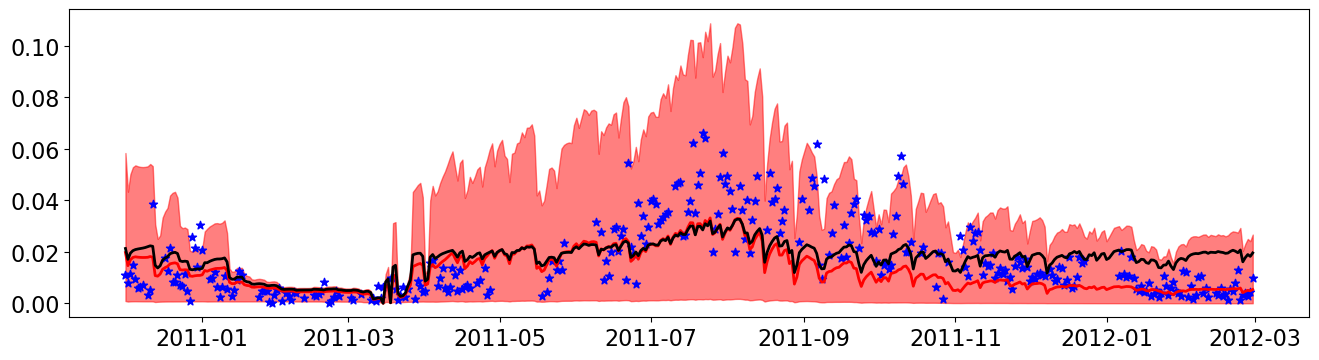

In [22]:
plt.figure(figsize = (16,4))
plt.fill_between(h2.date, min, max, color = "red", alpha = 0.5)
plt.plot(h2.date, data.mean(axis=1), "r", linewidth = 2)
plt.plot(h2.date, mVdd_m, "k", linewidth = 2)
plt.scatter(h2.date, vd, marker = "*", color="blue" )
#plt.savefig("validation.png")
plt.show()

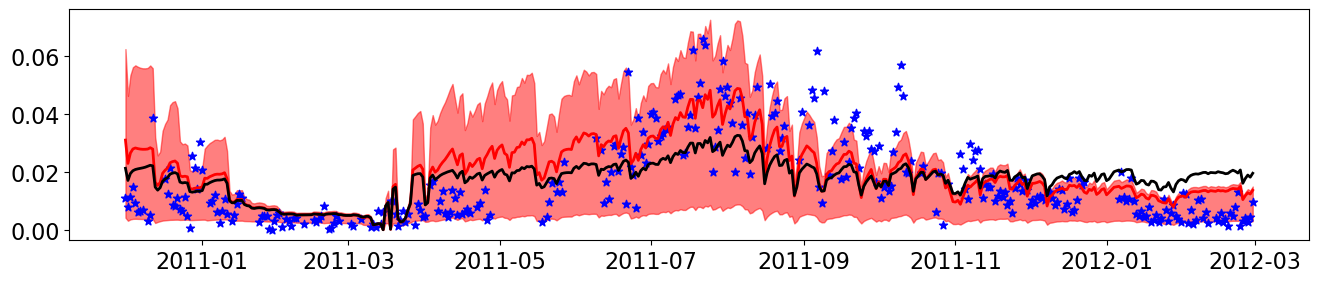

In [114]:
plt.figure(figsize = (16,3))
plt.fill_between(h2.date, data["vd_0_0_0"], data["vd_19_19_19"], color = "red", alpha = 0.5)
plt.plot(h2.date, data.mean(axis=1), "r", linewidth = 2)
plt.plot(h2.date, mVdd_m, "k", linewidth = 2)
plt.scatter(h2.date, vd, marker = "*", color="blue" )

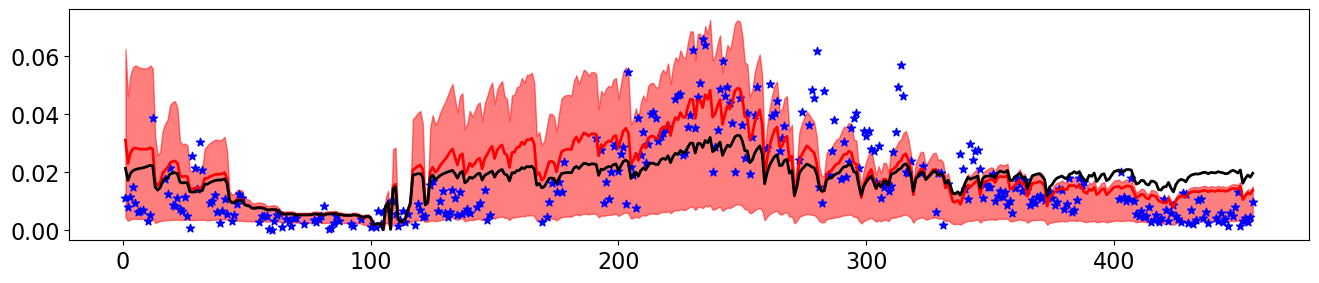

In [107]:
plt.figure(figsize = (16,3))
plt.fill_between(days, data["vd_0_0_0"], data["vd_19_19_19"], color = "red", alpha = 0.5)
plt.plot(days, data.mean(axis=1), "r", linewidth = 2)
plt.plot(days, mVdd, "k", linewidth = 2)
plt.scatter(days, vd, marker = "*", color="blue" )

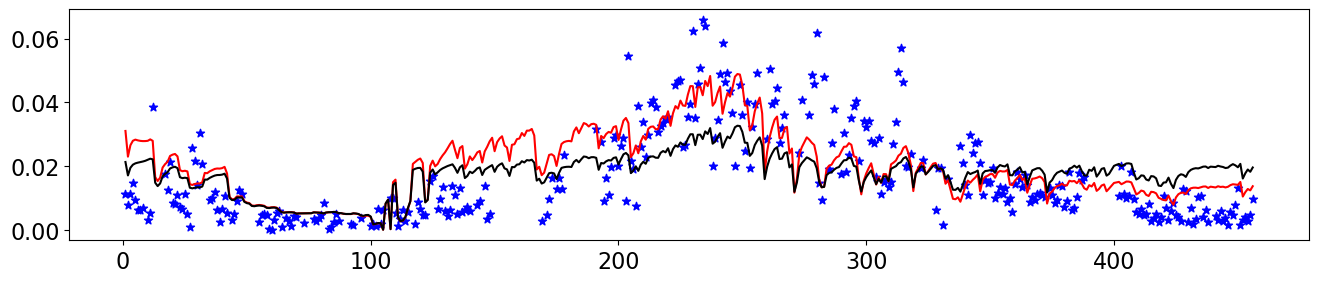

In [104]:
plt.figure(figsize=(16,3))
plt.plot(days, data.mean(axis=1), "r")
plt.plot(days, mVdd_m, "k")
plt.scatter(days, vd, marker = "*", color="blue" )

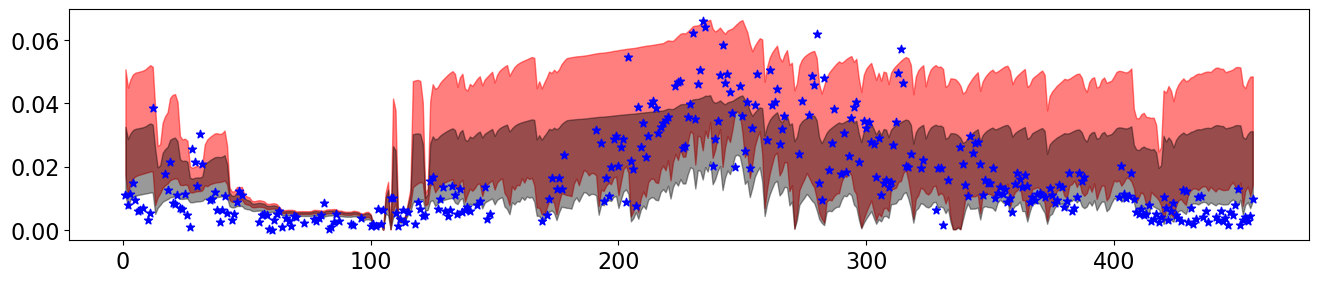

In [125]:
plt.figure(figsize=(16,3))
plt.fill_between(days, Vdd_d1, Vdd1, color="red", alpha=0.5)
plt.fill_between(days, mVdd, mVdd_d, color="k", alpha = 0.4)
plt.scatter(days, vd, marker = "*", color="blue")

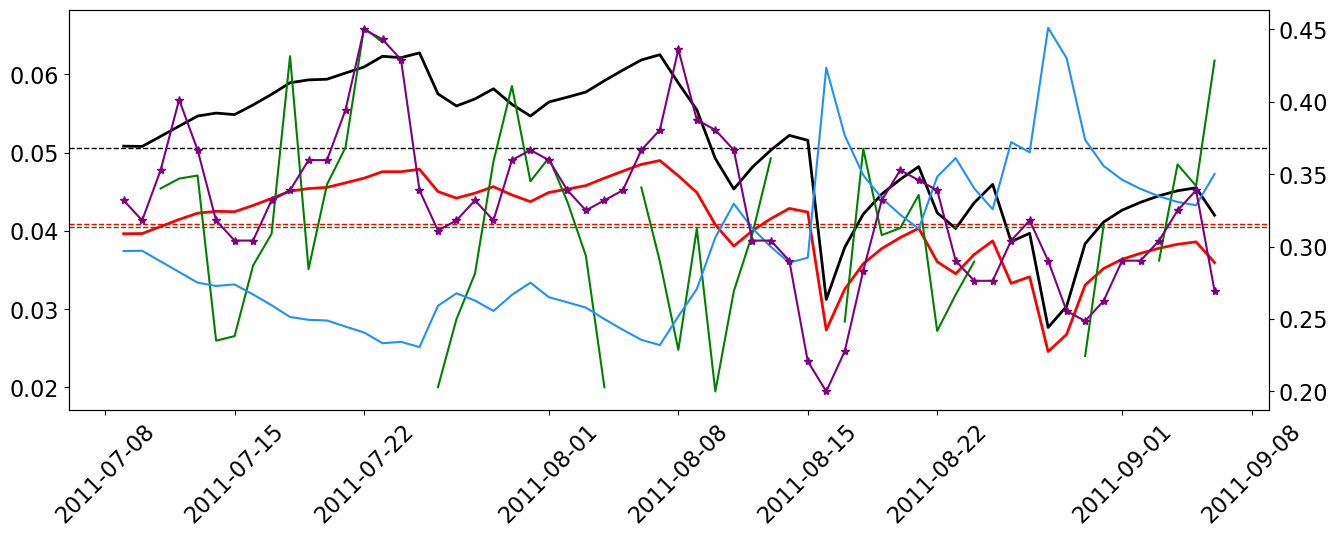

In [44]:
fig = plt.figure()
fig.set_figwidth(12)
fig.set_figheight(4)
ax1 = fig.add_axes([0,0,1,1])
#ax1.plot(days[0:60], Vd_mean_o[220:280], color="green", linestyle="dashed", linewidth=2)
#ax1.plot(days[0:60], Vd_wet_o[220:280], color="magenta", linestyle="dashed", linewidth=2)
ax1.plot(h2.date[220:280], Vd_o[220:280], color="red", linestyle="solid", linewidth=2)
ax1.axhline(y=Vd_o[220:280].mean(), color='red', linestyle='--', linewidth=1)
ax1.plot(h2.date[220:280], vd_dry_m[220:280], color="k", linewidth=2)
ax1.axhline(y=vd_dry_m[220:280].mean(), color='k', linestyle='--', linewidth=1)
ax1.plot(h2.date[220:280], vd[220:280], color = "green")
ax1.axhline(y=vd[220:280].mean(), color='green', linestyle='--', linewidth=1)
ax1.tick_params(axis='x', labelrotation=45)
ax2=ax1.twinx()
ax2.plot(h2.date[220:280], ss_dry[220:280], color="dodgerblue")
ax2.plot(h2.date[220:280], stemp_S, color="purple", marker="*");

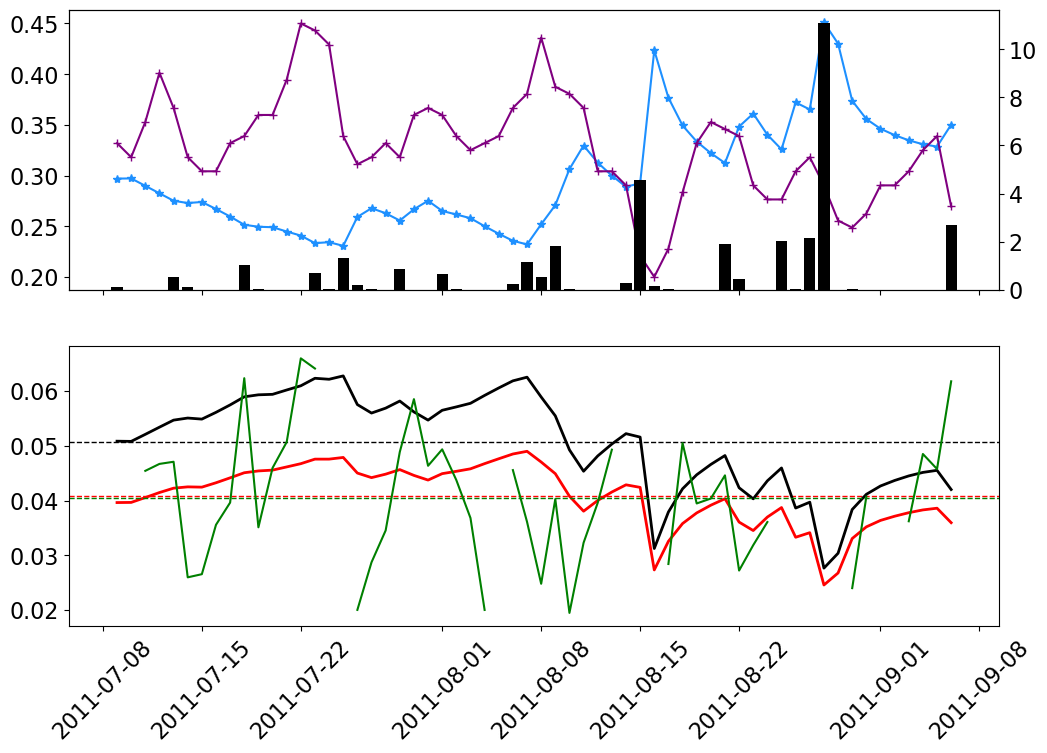

In [16]:
fig, axs = plt.subplots(2, 1, figsize=(12,8), sharex=True)
axs[0].plot(h2.date[220:280], ss_dry[220:280], color="dodgerblue", marker = "*")
axs[0].plot(h2.date[220:280], stemp_S, color="purple", marker = "+")
ax2 = axs[0].twinx()
ax2.bar(h2.date[220:280], precip[220:280], color="k")
axs[1].plot(h2.date[220:280], Vd_o[220:280], color="red", linestyle="solid", linewidth=2)
axs[1].axhline(y=Vd_o[220:280].mean(), color='red', linestyle='--', linewidth=1)
axs[1].plot(h2.date[220:280], vd_dry_m[220:280], color="k", linewidth=2)
axs[1].axhline(y=vd_dry_m[220:280].mean(), color='k', linestyle='--', linewidth=1)
axs[1].plot(h2.date[220:280], vd[220:280], color = "green")
axs[1].axhline(y=vd[220:280].mean(), color='green', linestyle='--', linewidth=1)
axs[1].tick_params(axis='x', labelrotation=45);